# Modelado: predicción de reingreso hospitalario

En este notebook se entrenan y comparan distintos modelos para predecir el reingreso a 30 días del alta.

El objetivo es ver qué algoritmo funciona mejor sobre el dataset preprocesado, antes de hacer el análisis en profundidad en el notebook de evaluación.

**Modelos evaluados:**
- Regresión Logística (baseline lineal)
- Random Forest (conjunto de árboles)
- XGBoost (gradient boosting)
- LightGBM (gradient boosting, más rápido)

**Métricas principales:** ROC-AUC y Recall. En contexto clínico lo más importante es detectar el máximo de pacientes en riesgo.

## 1. Imports y configuración

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, roc_auc_score

from src.models.train import (
    load_data, split_data, get_models,
    run_all_models, cross_validate_model, tune_model, get_metrics
)
from src.evaluation.evaluate import (
    plot_confusion_matrix, get_classification_report
)

## 2. Carga del dataset

In [2]:
X, y, groups = load_data()

print(f"Dataset: {X.shape[0]:,} registros — {X.shape[1]} variables predictoras")
print(f"\nDistribución de la variable objetivo:")
print(y.value_counts())
print(f"\nProporción positivos (readmisión): {y.mean():.1%}")

Dataset cargado: 315,982 registros, 54 variables. Tasa positivos: 0.342. Split: por paciente (GroupShuffleSplit)
Dataset: 315,982 registros — 54 variables predictoras

Distribución de la variable objetivo:
readmission_30_days
0    208032
1    107950
Name: count, dtype: int64

Proporción positivos (readmisión): 34.2%


### Nota sobre el desbalanceo de clases

La variable objetivo tiene un 65.8% de negativos y un 34.2% de positivos. Es un desbalanceo moderado, pero con el umbral por defecto de 0.5 los modelos tienden a ignorar la clase minoritaria y el recall en readmisión baja mucho.

Para corregirlo ajusto los pesos de clase dándole más peso a la clase minoritaria. En Regresión Logística y Random Forest uso `class_weight='balanced'`; en XGBoost y LightGBM uso `scale_pos_weight = N_neg / N_pos` (≈ 1.92). Así el modelo penaliza más los falsos negativos, que es lo que más importa: es peor no detectar un reingreso que generar una alerta de más.

## 3. División en entrenamiento, validación y test

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, groups)

print(f"Train: {X_train.shape[0]:,} registros ({y_train.mean():.1%} positivos)")
print(f"Val:   {X_val.shape[0]:,} registros ({y_val.mean():.1%} positivos)")
print(f"Test:  {X_test.shape[0]:,} registros ({y_test.mean():.1%} positivos)")

Train: 189,245 registros (34.2% positivos)
Val:   62,611 registros (33.8% positivos)
Test:  64,126 registros (34.6% positivos)


## 4. Entrenamiento y comparación de modelos

Los modelos se ordenan por ROC-AUC usando Average Precision como desempate. Las métricas se evalúan sobre el **conjunto de validación**, reservando el test set para el final.

In [4]:
results_df, trained_models = run_all_models(X_train, X_val, y_train, y_val)
results_df

Training models...
  Training Logistic Regression...
  Training Random Forest...
  Training XGBoost...
  Training LightGBM...


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Avg Precision,Train time (s)
Model,,,,,,,
LightGBM,0.6135,0.4451,0.5866,0.5062,0.6509,0.4816,1.6
XGBoost,0.6142,0.4455,0.5819,0.5046,0.6500,0.4820,3.2
Logistic Regression,0.6133,0.4412,0.5443,0.4873,0.6327,0.4537,1.0
Random Forest,0.6493,0.4578,0.2093,0.2873,0.6094,0.4267,20.1


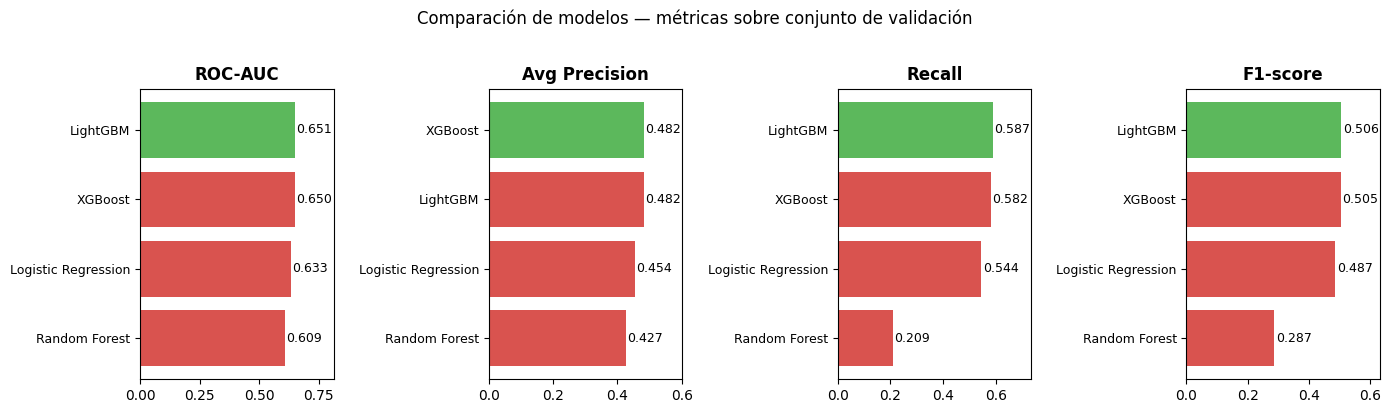

In [5]:
# Gráfico comparativo de modelos en las métricas clave
metrics_to_plot = ["ROC-AUC", "Avg Precision", "Recall", "F1-score"]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, metric in zip(axes, metrics_to_plot):
    values = results_df[metric].sort_values()
    colors = ["#d9534f" if m != results_df[metric].idxmax() else "#5cb85c" for m in values.index]
    bars = ax.barh(values.index, values.values, color=colors)
    ax.set_xlim(0, max(values.values) * 1.25)
    ax.set_title(metric, fontweight="bold")
    ax.set_xlabel("")
    for bar, val in zip(bars, values.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Comparación de modelos — métricas sobre conjunto de validación", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../results/model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### Justificación de la selección del modelo

Para elegir el modelo final miré tres cosas: rendimiento (ROC-AUC), recall clínico e interpretabilidad con SHAP.

**Regresión Logística** queda como baseline. Su AUC de 0.633 es el más bajo y el modelo lineal no captura bien las interacciones entre variables clínicas.

**Random Forest** se descarta porque su Recall es de solo 0.21, es decir, detecta 1 de cada 5 reingresos reales. Para screening clínico eso no sirve.

**XGBoost y LightGBM** dan resultados casi idénticos (AUC 0.6509 vs 0.6500). Se elige **LightGBM** porque tiene el AUC marginalmente superior, que es la métrica principal. Tras la optimización, el modelo final alcanza un AUC de 0.6567 en test.

El análisis detallado está en `04_evaluation.ipynb`.

## 4.1 Curvas ROC: comparación de los cuatro modelos base


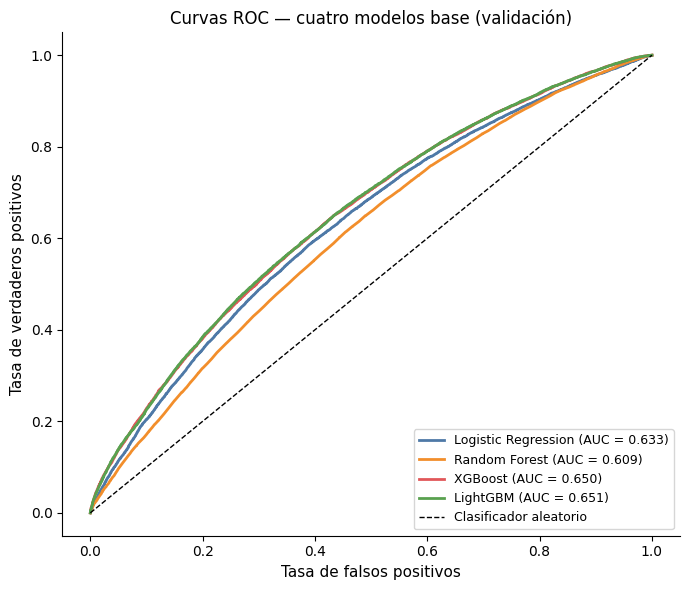

Guardado: results/roc_4models.png


In [6]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Solo los 4 modelos base, evaluados sobre validación
base_models = {k: v for k, v in trained_models.items() if "tuned" not in k.lower()}

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#4e79a7", "#f28e2b", "#e15759", "#59a14f"]

for (name, model), color in zip(base_models.items(), colors):
    y_prob = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
ax.set_xlabel("Tasa de falsos positivos", fontsize=11)
ax.set_ylabel("Tasa de verdaderos positivos", fontsize=11)
ax.set_title("Curvas ROC — cuatro modelos base (validación)", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/roc_4models.png", dpi=180, bbox_inches="tight")
plt.show()
print("Guardado: results/roc_4models.png")

## 5. Validación cruzada del mejor modelo

Aquí se hace CV de 5 folds solo sobre train para ver si el modelo es estable. Ni val ni test se tocan en este paso.

El AUC del CV sale algo inferior al del modelo entrenado con todo train, lo cual es normal porque cada fold entrena con menos datos.

In [ ]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print(f"Mejor modelo: {best_model_name}")
print(f"ROC-AUC (val): {results_df.loc[best_model_name, 'ROC-AUC']}")

# CV solo sobre train — ni val ni test participan aquí
groups_train = groups.loc[X_train.index]
cv_results = cross_validate_model(best_model, X_train, y_train, cv=5, groups=groups_train)
print(f"ROC-AUC (CV 5-fold sobre train): {cv_results['cv_roc_auc_mean']} ± {cv_results['cv_roc_auc_std']}")

## 6. Optimización de hiperparámetros

Los modelos anteriores iban con los hiperparámetros por defecto. Aquí pruebo a mejorar LightGBM con `RandomizedSearchCV`.

Se hacen 20 combinaciones aleatorias con CV de 3 folds, solo sobre `X_train`. El scoring es ROC-AUC. Con los mejores parámetros se reentrena sobre todo `X_train` y luego se evalúa en test.

In [ ]:
groups_train = groups.loc[X_train.index]
best_model_tuned, best_params, tune_cv = tune_model(
    best_model_name, X_train, y_train, n_iter=20, cv=3, groups=groups_train
)

# comparamos baseline y optimizado sobre test
# (results_df tenía métricas de validación, aquí los dos se evalúan en test)
y_pred_base  = trained_models[best_model_name].predict(X_test)
y_prob_base  = trained_models[best_model_name].predict_proba(X_test)[:, 1]
metrics_base_test = get_metrics(y_test, y_pred_base, y_prob_base)

y_pred_tuned = best_model_tuned.predict(X_test)
y_prob_tuned = best_model_tuned.predict_proba(X_test)[:, 1]
metrics_tuned = get_metrics(y_test, y_pred_tuned, y_prob_tuned)

print("\n--- Comparación baseline vs optimizado (ambos sobre test set) ---")
print(f"{'Métrica':<18} {'Baseline':>10} {'Optimizado':>10} {'Mejora':>10}")
print("-" * 50)
for metric in ["ROC-AUC", "Avg Precision", "Recall", "F1-score"]:
    baseline = round(metrics_base_test[metric], 4)
    tuned    = round(metrics_tuned[metric], 4)
    diff     = round(tuned - baseline, 4)
    sign     = "+" if diff >= 0 else ""
    print(f"{metric:<18} {baseline:>10.4f} {tuned:>10.4f} {sign+str(diff):>10}")

print(f"\nROC-AUC (CV interna optimización, 3 folds): {tune_cv['cv_roc_auc_mean']} ± {tune_cv['cv_roc_auc_std']}")

# el optimizado es el modelo principal de aquí en adelante
best_model = best_model_tuned
best_model_name = f"{best_model_name} (optimizado)"
trained_models[best_model_name] = best_model

## 7. Curvas ROC: comparación de modelos

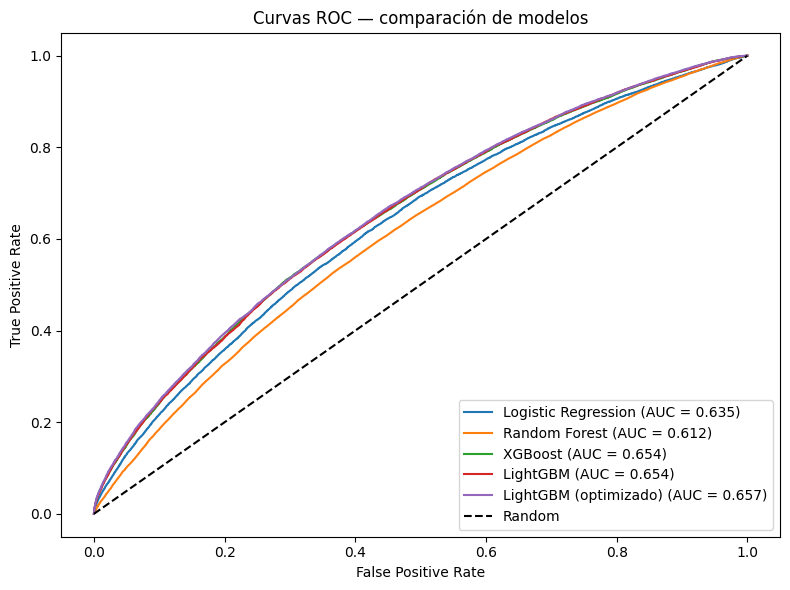

In [9]:
plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — comparación de modelos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../results/roc_curves_comparison.png", dpi=150)
plt.show()

## 8. Matriz de confusión del mejor modelo

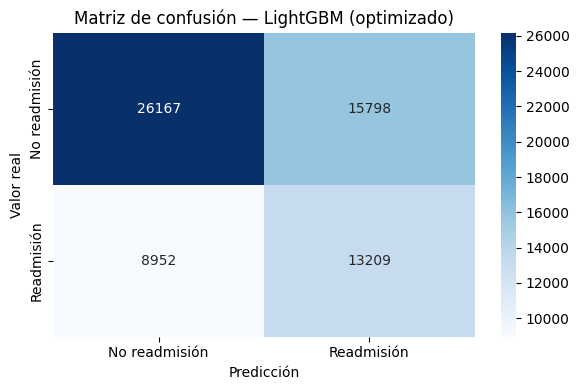


Classification Report:
               precision  recall  f1-score    support
No readmisión      0.745   0.624     0.679  41965.000
Readmisión         0.455   0.596     0.516  22161.000
accuracy           0.614   0.614     0.614      0.614
macro avg          0.600   0.610     0.598  64126.000
weighted avg       0.645   0.614     0.623  64126.000


In [10]:
plot_confusion_matrix(
    best_model, X_test, y_test, best_model_name,
    save_path="../results/confusion_matrix_best.png"
)

print("\nClassification Report:")
print(get_classification_report(best_model, X_test, y_test).to_string())

## 9. Guardado de resultados

In [ ]:
import glob as _glob

# añadimos las métricas del optimizado y guardamos
tuned_row = pd.DataFrame([{**metrics_tuned, "Train time (s)": np.nan}], index=[best_model_name])
tuned_row = tuned_row.round(4)
results_full = pd.concat([results_df, tuned_row])
results_full.to_csv("../results/model_comparison.csv")

# borramos pkls anteriores para que el notebook 04 no cargue uno viejo
for old_path in _glob.glob("../models/*.pkl"):
    os.remove(old_path)

# guardamos el modelo final
model_path = f"../models/{best_model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}.pkl"
joblib.dump(best_model, model_path)

print(f"Métricas guardadas en results/model_comparison.csv")
print(f"Mejor modelo guardado en {model_path}")
print(f"\nTabla final:")
results_full[["Accuracy", "Recall", "F1-score", "ROC-AUC", "Avg Precision"]]

## 10. Conclusiones

**XGBoost y LightGBM** dan resultados prácticamente iguales (diferencia de 0.0009 AUC). Tiene sentido, los dos son implementaciones de gradient boosting y con este volumen de datos tienden a converger.

**Sobre la división de datos:** se dividió por paciente (`subject_id`) con `GroupShuffleSplit` para que ningún paciente aparezca a la vez en train y test. Al comparar con la división aleatoria las métricas difieren menos de 0.002 AUC, lo que indica que el modelo aprende patrones reales y no se beneficia de haber visto admisiones del mismo paciente antes.

Un AUC de 0.65-0.67 está en línea con lo que sale en la literatura para reingreso a 30 días con datos administrativos (LACE+: 0.63-0.72). Sin variables clínicas como signos vitales o analíticas, el modelo no puede ir mucho más allá.

El análisis en profundidad se hace en `04_evaluation.ipynb`.